# Optional Lab: Image Classification with Fourier Transform Features

This optional notebook repeats the classification idea from the earlier image-classification labs, but it changes the question we ask of each image.

Instead of giving the model raw pixels, we use the **Fourier transform** to describe how much low-, middle-, and high-frequency pattern exists in each image. In plain language: the model gets a compact summary of smooth regions, broad shapes, edges, and fine texture.

## 1. Imports and workshop helpers

In [1]:
# Standard library tools for file paths, timing, and warnings.
from pathlib import Path
import math
import sys
import time
import warnings

# Data-science libraries for arrays, tables, plots, and images.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# Classical machine-learning models and evaluation tools.
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Find the notebook folder so imports and dataset paths work from either the
# repository root or the 0_Class_Notebooks folder.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "0_Class_Notebooks":
    candidate = NOTEBOOK_DIR / "0_Class_Notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from workshop_image_utils import (
    available_target_modes,
    load_image_records,
    load_images_as_arrays,
    record_timing,
    safe_stratify_labels,
    target_column_for_mode,
    timing_frame,
    validate_target_mode,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

step_timings = []

## 2. Configuration

In [2]:
DATASET_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Device_Images").resolve()
METADATA_PATH = DATASET_ROOT / "metadata.csv"

# Student change points.
TARGET_MODE = "damage_status"  # Try "device_type" to classify device family instead.
INCLUDED_DEVICE_TYPES = ["device1", "device 2"]
IMAGE_SIZE = 96
TEST_SIZE = 0.30
RANDOM_STATE = 42

# Fourier feature choices.
FOURIER_BINS = 24  # More bins keep more frequency detail; fewer bins are simpler.
LOW_FREQUENCY_CUTOFF = 0.00  # Try 0.05 to ignore the very broadest image structure.
HIGH_FREQUENCY_CUTOFF = 1.00  # Try 0.55 or 0.75 to ignore the finest texture/noise.
INCLUDE_BRIGHTNESS_FEATURES = True

# Pixel baseline choices for comparison.
RUN_PIXEL_BASELINE = True
USE_PIXEL_PCA = True
PCA_VARIANCE_TO_KEEP = 0.95

print(f"Dataset root: {DATASET_ROOT}")
print(f"Metadata file exists: {METADATA_PATH.exists()}")
print(f"Target mode: {TARGET_MODE}")
print(f"Fourier bins: {FOURIER_BINS}")
print(f"Frequency range kept: {LOW_FREQUENCY_CUTOFF:.2f} to {HIGH_FREQUENCY_CUTOFF:.2f}")

Dataset root: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Metadata file exists: True
Target mode: damage_status
Fourier bins: 24
Frequency range kept: 0.00 to 1.00


## 3. Load the dataset

In [3]:
started = time.perf_counter()
all_records = load_image_records(DATASET_ROOT, metadata_path=METADATA_PATH if METADATA_PATH.exists() else None)
record_timing(step_timings, "dataset_scan", started)

standard_device_records = all_records[all_records["is_standard_device_image"]].reset_index(drop=True)
standard_device_records = standard_device_records[
    standard_device_records["device_type"].isin(INCLUDED_DEVICE_TYPES)
].reset_index(drop=True)
defect_records = all_records[all_records["is_defect_challenge"]].reset_index(drop=True)

if TARGET_MODE == "device_type":
    records = standard_device_records.copy()
else:
    records = pd.concat([standard_device_records, defect_records], ignore_index=True)

print(f"All records found: {len(all_records)}")
print(f"Standard device records after filtering: {len(standard_device_records)}")
print(f"Defect records available: {len(defect_records)}")
print("Available target modes:", available_target_modes(records))

is_valid_target, target_message = validate_target_mode(records, TARGET_MODE)
print(target_message)
if not is_valid_target:
    raise ValueError(target_message)

target_column = target_column_for_mode(TARGET_MODE)
records = records[records[target_column].notna()].reset_index(drop=True)
display(records.head())

All records found: 80
Standard device records after filtering: 40
Defect records available: 40
Available target modes: ['device_type', 'damage_status']
Target `damage_status` is ready with classes: ['Damaged', 'Not-Damaged']


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge
0,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
1,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
2,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_002.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
3,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_010.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
4,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_018.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False


## 4. Class balance

,count
damage_status,
Damaged,40
Not-Damaged,40


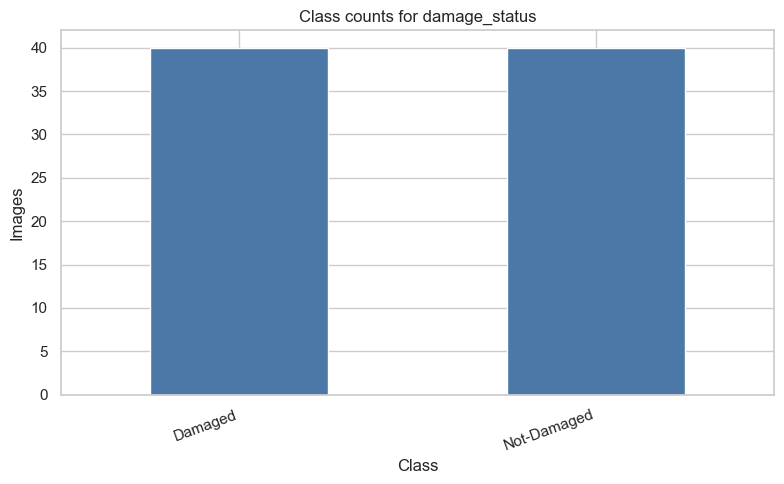

In [4]:
class_counts = records[target_column].value_counts(dropna=True).sort_index()
display(class_counts.rename("count").to_frame())

ax = class_counts.plot(kind="bar", color="#4c78a8", title=f"Class counts for {TARGET_MODE}")
ax.set_xlabel("Class")
ax.set_ylabel("Images")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Load grayscale images

In [5]:
started = time.perf_counter()
image_arrays, filtered_records = load_images_as_arrays(
    records,
    image_size=IMAGE_SIZE,
    color_mode="grayscale",
    progress_title="Load grayscale images",
)
record_timing(step_timings, "load_grayscale_images", started)

labels = filtered_records[target_column].astype(str).to_numpy()
images_scaled = image_arrays.astype(float) / 255.0

print("Image array shape:", image_arrays.shape)
print("Labels shape:", labels.shape)

Image array shape: (80, 96, 96)
Labels shape: (80,)


## 6. What the Fourier transform shows

The Fourier transform turns an image into a map of frequencies.

- The center of the frequency image represents broad, slow-changing structure.
- Farther from the center represents sharper edges and fine texture.
- We use `log1p` only for display because raw frequency magnitudes can have a very large range.

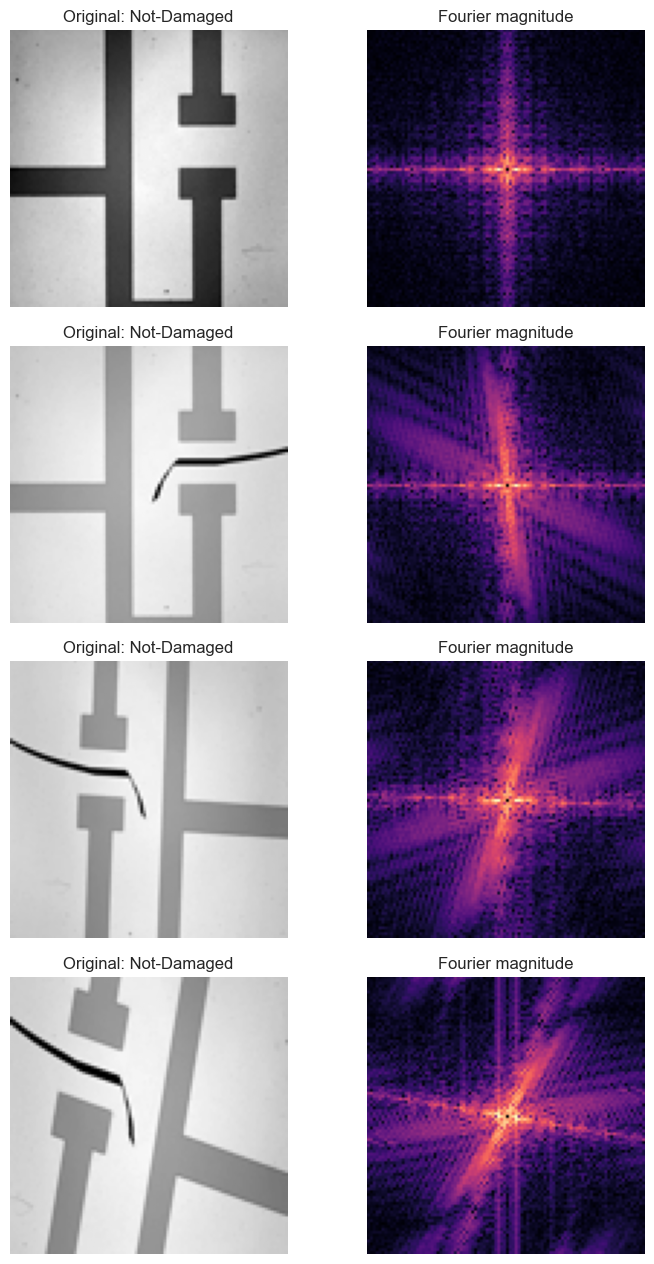

In [6]:
def fourier_magnitude_image(image_2d):
    centered = image_2d.astype(float) - image_2d.mean()
    spectrum = np.fft.fftshift(np.fft.fft2(centered))
    magnitude = np.log1p(np.abs(spectrum))
    return magnitude


example_count = min(4, len(images_scaled))
fig, axes = plt.subplots(example_count, 2, figsize=(8, 3.2 * example_count))
axes = np.atleast_2d(axes)

for row_index in range(example_count):
    image = images_scaled[row_index]
    label = labels[row_index]
    axes[row_index, 0].imshow(image, cmap="gray")
    axes[row_index, 0].set_title(f"Original: {label}")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(fourier_magnitude_image(image), cmap="magma")
    axes[row_index, 1].set_title("Fourier magnitude")
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()

## 7. Convert each image into Fourier features

In [7]:
def make_frequency_masks(image_size, n_bins, low_cutoff=0.0, high_cutoff=1.0):
    y, x = np.indices((image_size, image_size))
    center = (image_size - 1) / 2
    radius = np.sqrt((x - center) ** 2 + (y - center) ** 2)
    radius = radius / radius.max()

    edges = np.linspace(low_cutoff, high_cutoff, n_bins + 1)
    masks = []
    labels_for_bins = []
    for start, stop in zip(edges[:-1], edges[1:]):
        mask = (radius >= start) & (radius < stop)
        if mask.any():
            masks.append(mask)
            labels_for_bins.append(f"freq_{start:.2f}_{stop:.2f}")
    return masks, labels_for_bins


def extract_fourier_features(images, n_bins=24, low_cutoff=0.0, high_cutoff=1.0, include_brightness=True):
    masks, names = make_frequency_masks(images.shape[1], n_bins, low_cutoff, high_cutoff)
    rows = []

    for image in images:
        centered = image - image.mean()
        spectrum = np.fft.fftshift(np.fft.fft2(centered))
        power = np.abs(spectrum) ** 2
        total_power = power.sum() + 1e-12

        row = []
        for mask in masks:
            band_energy = power[mask].sum() / total_power
            row.append(np.log1p(band_energy * 1_000_000))

        if include_brightness:
            row.extend([image.mean(), image.std()])

        rows.append(row)

    feature_names = names.copy()
    if include_brightness:
        feature_names.extend(["mean_brightness", "contrast"])

    return np.array(rows), feature_names


started = time.perf_counter()
X_fourier, fourier_feature_names = extract_fourier_features(
    images_scaled,
    n_bins=FOURIER_BINS,
    low_cutoff=LOW_FREQUENCY_CUTOFF,
    high_cutoff=HIGH_FREQUENCY_CUTOFF,
    include_brightness=INCLUDE_BRIGHTNESS_FEATURES,
)
record_timing(step_timings, "fourier_feature_extraction", started)

print("Fourier feature matrix shape:", X_fourier.shape)
display(pd.DataFrame(X_fourier, columns=fourier_feature_names).head())

Fourier feature matrix shape: (80, 26)


,freq_0.00_0.04,freq_0.04_0.08,freq_0.08_0.12,freq_0.12_0.17,freq_0.17_0.21,freq_0.21_0.25,freq_0.25_0.29,freq_0.29_0.33,freq_0.33_0.38,freq_0.38_0.42,...,freq_0.67_0.71,freq_0.71_0.75,freq_0.75_0.79,freq_0.79_0.83,freq_0.83_0.88,freq_0.88_0.92,freq_0.92_0.96,freq_0.96_1.00,mean_brightness,contrast
0,12.665324,12.978943,11.512735,10.091398,10.450427,10.418431,9.081166,8.833780,9.455441,9.064363,...,7.539324,5.110287,3.972111,3.491793,3.038140,2.606262,2.031290,0.994177,0.607793,0.089685
1,12.379349,12.645781,11.660875,11.218430,11.153801,10.721237,10.153165,10.136385,10.366179,9.882320,...,7.827446,6.669194,6.154688,5.543934,5.218147,4.477255,3.561668,2.493014,0.601568,0.102303
2,12.029342,12.830431,11.737222,11.512991,10.758079,10.515478,10.536763,10.347882,9.944200,9.677414,...,7.733100,6.879378,5.870227,4.966441,4.100727,3.372166,2.906620,1.749554,0.690475,0.122385
3,12.352653,12.693181,11.918751,11.214303,10.721517,10.804530,10.531878,9.888171,9.827406,9.558595,...,7.807511,7.366577,6.379550,6.073247,5.392690,4.093663,2.995315,1.623173,0.580293,0.121914
4,12.014826,12.824970,11.712071,11.517645,10.784925,10.565321,10.533848,10.293733,10.014461,9.747568,...,7.820525,6.808323,6.163176,5.249199,4.345964,3.629814,3.063833,1.888076,0.583622,0.101866


## 8. Inspect the average frequency profile by class

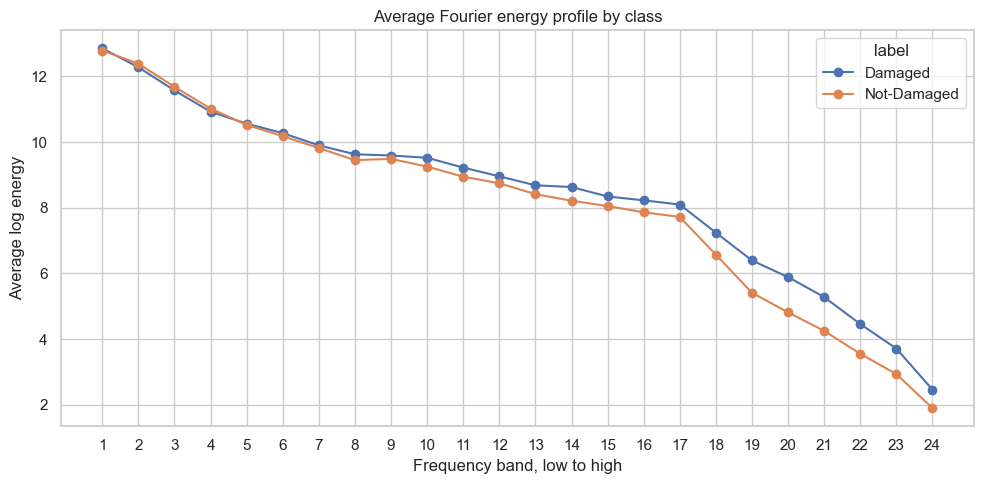

In [8]:
fourier_frame = pd.DataFrame(X_fourier, columns=fourier_feature_names)
fourier_frame["label"] = labels

frequency_columns = [name for name in fourier_feature_names if name.startswith("freq_")]
profile = fourier_frame.groupby("label")[frequency_columns].mean().T

ax = profile.plot(figsize=(10, 5), marker="o", title="Average Fourier energy profile by class")
ax.set_xlabel("Frequency band, low to high")
ax.set_ylabel("Average log energy")
ax.set_xticks(range(len(frequency_columns)))
ax.set_xticklabels(range(1, len(frequency_columns) + 1), rotation=0)
plt.tight_layout()
plt.show()

## 9. Train/test split

In [9]:
stratify_labels = safe_stratify_labels(labels)
X_train, X_test, y_train, y_test, train_images, test_images, train_records, test_records = train_test_split(
    X_fourier,
    labels,
    images_scaled,
    filtered_records,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

print("Train set size:", len(X_train))
print("Test set size:", len(X_test))
print("Used stratified split:", stratify_labels is not None)

Train set size: 56
Test set size: 24
Used stratified split: True


## 10. Shared evaluation helpers

In [10]:
model_summaries = []


def show_prediction_gallery(images, truths, preds, indices, title, max_images=6):
    selected = list(indices)[:max_images]
    if not selected:
        display(Markdown(f"**{title}:** none available in this split."))
        return

    columns = min(3, len(selected))
    rows = math.ceil(len(selected) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, selected):
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(f"True: {truths[idx]}\nPred: {preds[idx]}", fontsize=10)
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def evaluate_model(model_name, estimator, X_train, y_train, X_test, y_test, test_images, cmap="Blues"):
    started = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_seconds = record_timing(step_timings, model_name.lower().replace(" ", "_"), started)

    preds = estimator.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    model_summaries.append({"model": model_name, "accuracy": accuracy, "train_seconds": train_seconds})

    print(f"{model_name} accuracy: {accuracy:.3f}")
    print(classification_report(y_test, preds))

    labels_sorted = sorted(pd.unique(np.array(y_test, dtype=object)))
    cm = confusion_matrix(y_test, preds, labels=labels_sorted)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.title(f"{model_name} confusion matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

    correct_indices = [idx for idx, (truth, pred) in enumerate(zip(y_test, preds)) if truth == pred]
    incorrect_indices = [idx for idx, (truth, pred) in enumerate(zip(y_test, preds)) if truth != pred]
    show_prediction_gallery(test_images, y_test, preds, correct_indices, f"{model_name}: correct examples")
    show_prediction_gallery(test_images, y_test, preds, incorrect_indices, f"{model_name}: incorrect examples")

    return {"model": estimator, "predictions": preds, "accuracy": accuracy}

## 11. Logistic regression on Fourier features

Fourier Logistic Regression accuracy: 0.792
              precision    recall  f1-score   support

     Damaged       0.73      0.92      0.81        12
 Not-Damaged       0.89      0.67      0.76        12

    accuracy                           0.79        24
   macro avg       0.81      0.79      0.79        24
weighted avg       0.81      0.79      0.79        24



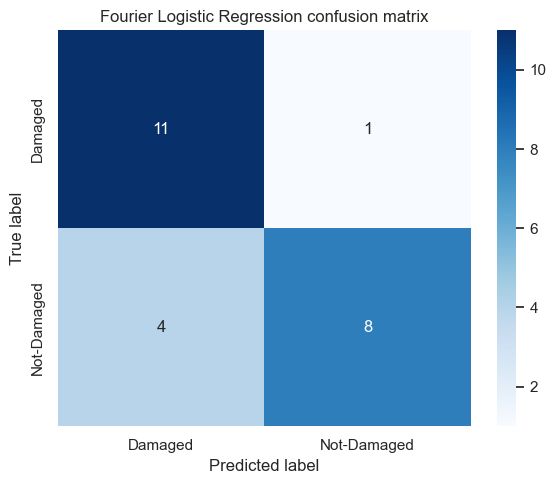

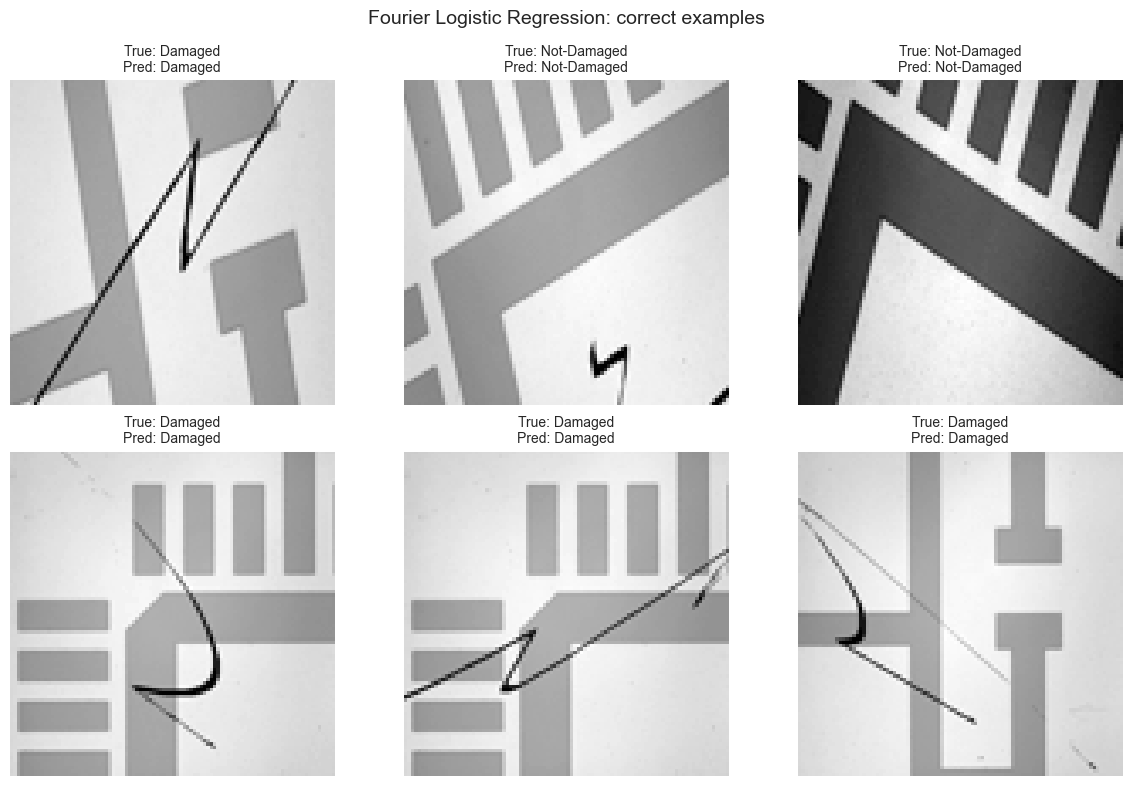

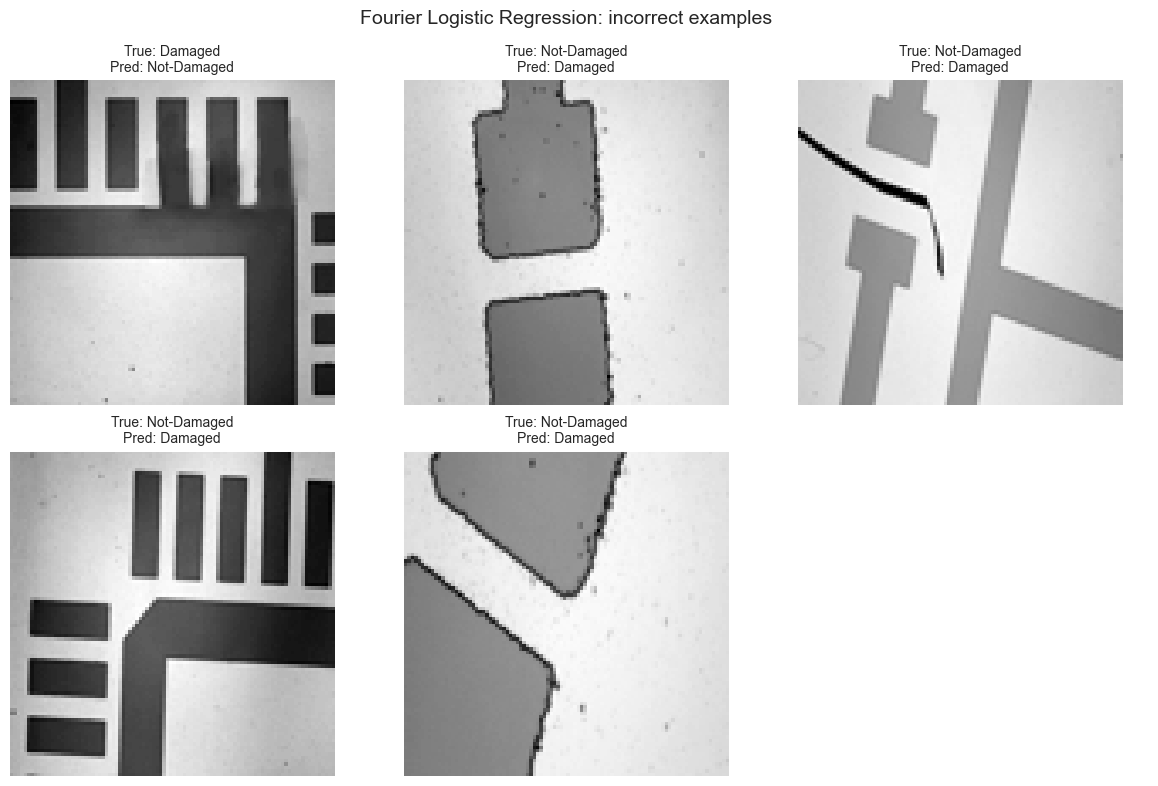

In [11]:
fourier_logistic_model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000)),
])

fourier_logistic_results = evaluate_model(
    "Fourier Logistic Regression",
    fourier_logistic_model,
    X_train,
    y_train,
    X_test,
    y_test,
    test_images,
    cmap="Blues",
)

## 12. Linear SVC on Fourier features

Fourier Linear SVC accuracy: 0.542
              precision    recall  f1-score   support

     Damaged       0.53      0.67      0.59        12
 Not-Damaged       0.56      0.42      0.48        12

    accuracy                           0.54        24
   macro avg       0.54      0.54      0.53        24
weighted avg       0.54      0.54      0.53        24



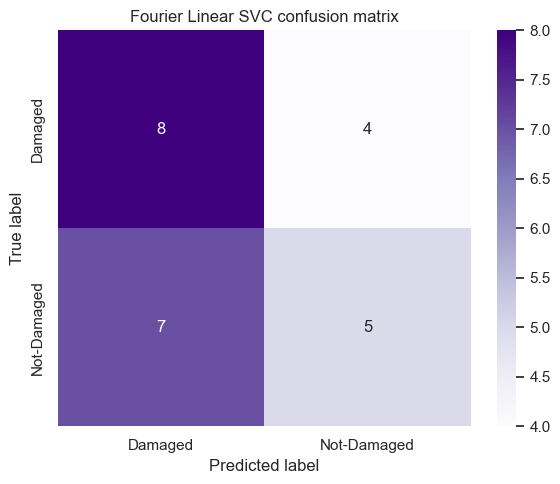

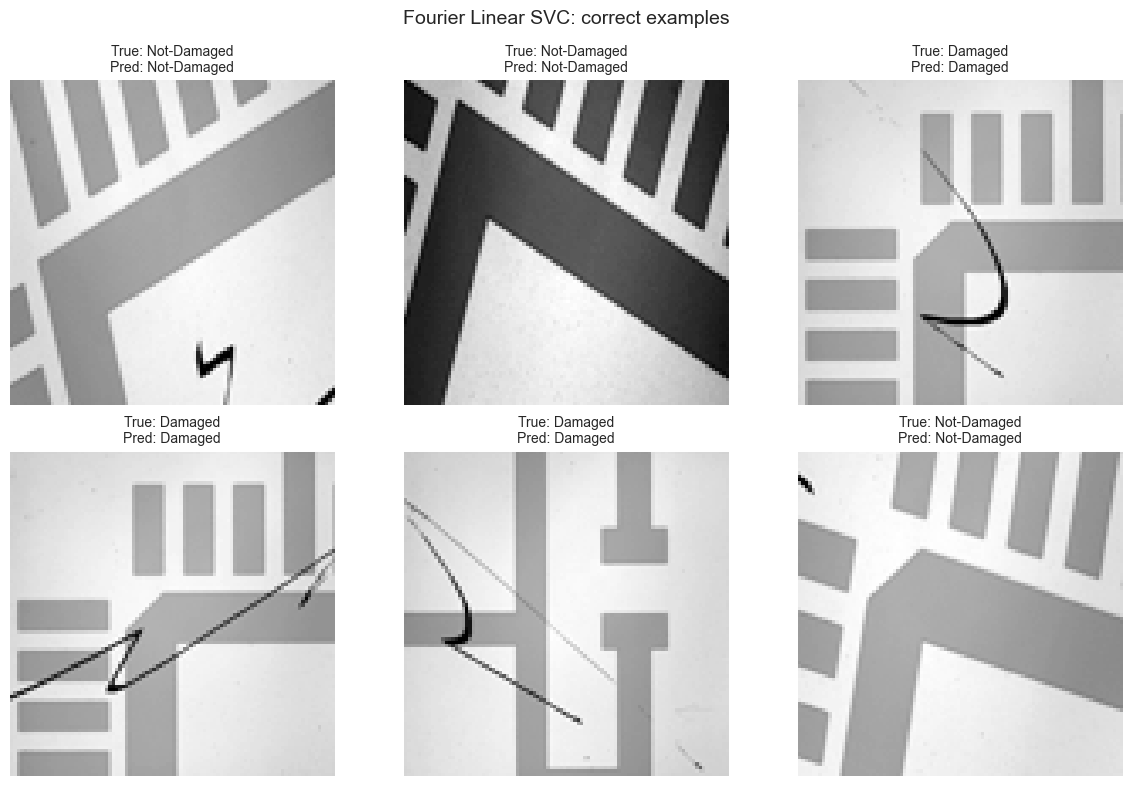

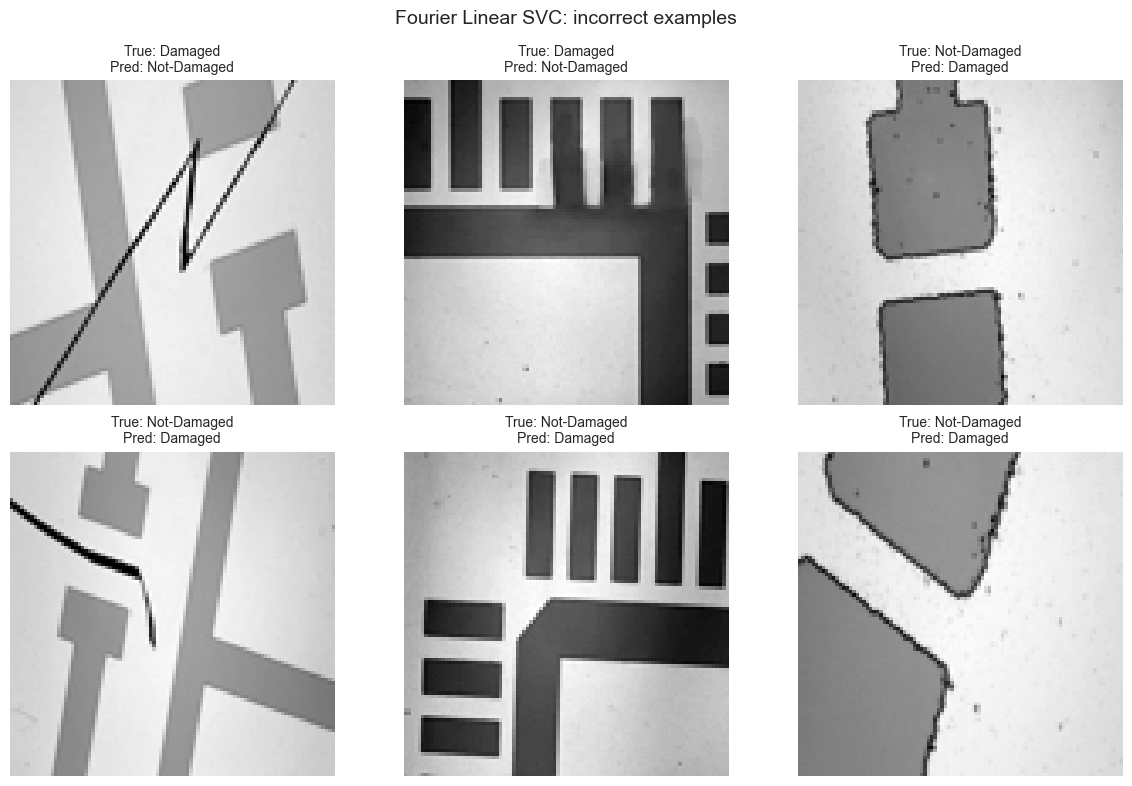

In [12]:
fourier_svc_model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LinearSVC(max_iter=5000, random_state=RANDOM_STATE)),
])

fourier_svc_results = evaluate_model(
    "Fourier Linear SVC",
    fourier_svc_model,
    X_train,
    y_train,
    X_test,
    y_test,
    test_images,
    cmap="Purples",
)

## 13. Which frequency bands mattered?

,feature,importance
12,freq_0.50_0.54,1.397996
20,freq_0.83_0.88,0.911332
13,freq_0.54_0.58,0.784215
15,freq_0.62_0.67,0.723652
14,freq_0.58_0.62,0.657333
11,freq_0.46_0.50,0.628297
6,freq_0.25_0.29,0.595199
5,freq_0.21_0.25,0.569487
21,freq_0.88_0.92,0.567251
10,freq_0.42_0.46,0.556820


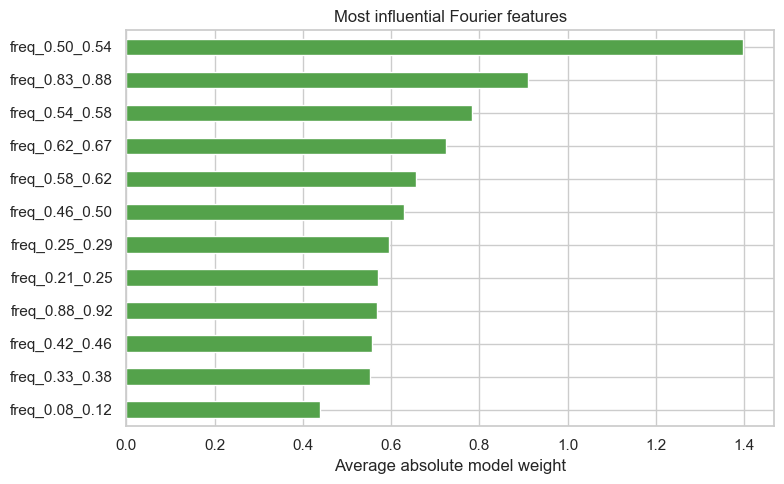

In [13]:
classifier = fourier_logistic_model.named_steps["clf"]
coef = np.abs(classifier.coef_)
importance = coef.mean(axis=0) if coef.ndim == 2 else coef

importance_frame = pd.DataFrame({
    "feature": fourier_feature_names,
    "importance": importance,
}).sort_values("importance", ascending=False)

display(importance_frame.head(10))

ax = importance_frame.head(12).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    color="#54a24b",
    title="Most influential Fourier features",
)
ax.set_xlabel("Average absolute model weight")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 14. Optional baseline: raw pixels with PCA

This section gives us a fair question: did the Fourier transform help, or did it throw away useful location information?

Pixel Logistic Regression accuracy: 0.625
              precision    recall  f1-score   support

     Damaged       0.64      0.58      0.61        12
 Not-Damaged       0.62      0.67      0.64        12

    accuracy                           0.62        24
   macro avg       0.63      0.62      0.62        24
weighted avg       0.63      0.62      0.62        24



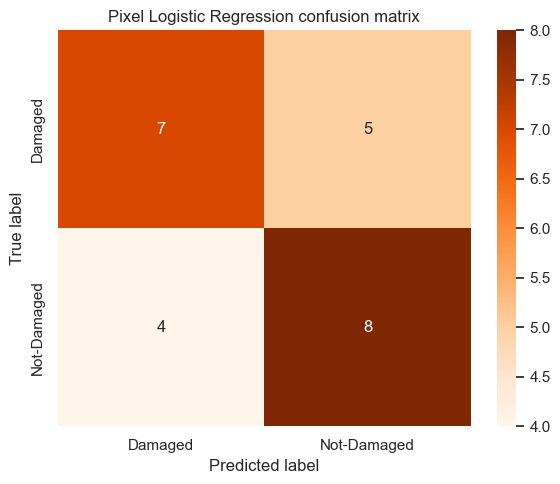

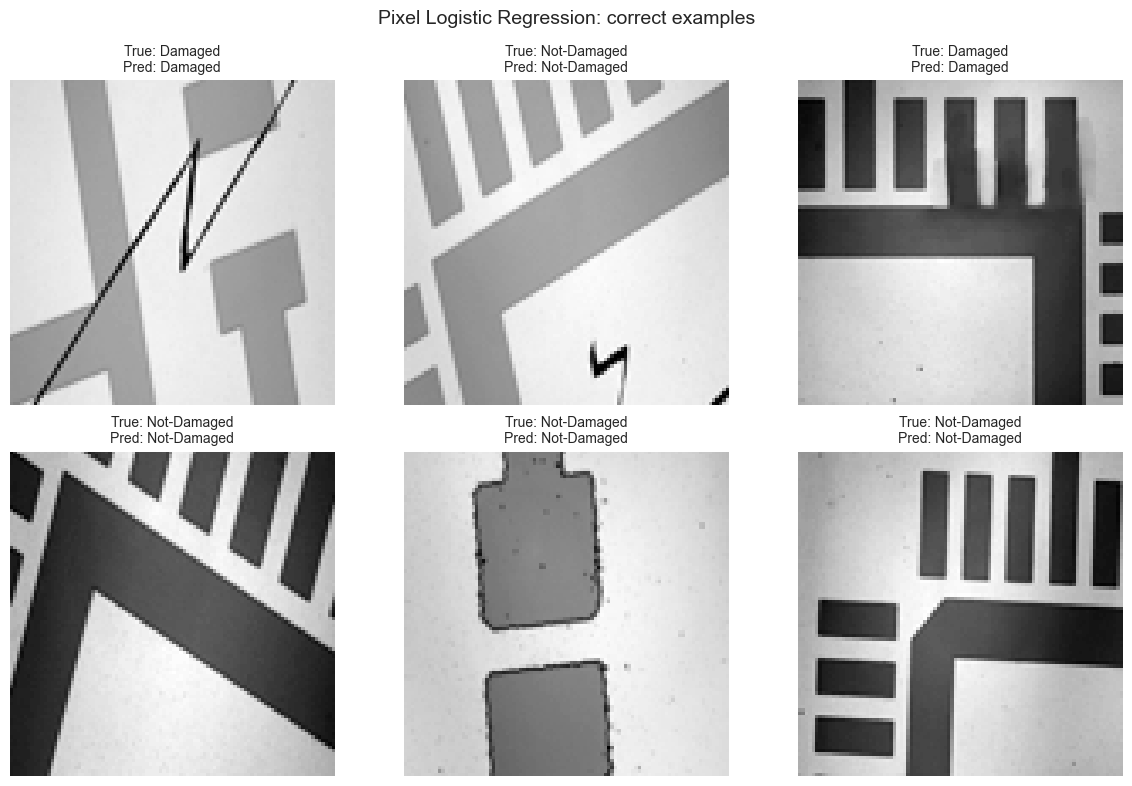

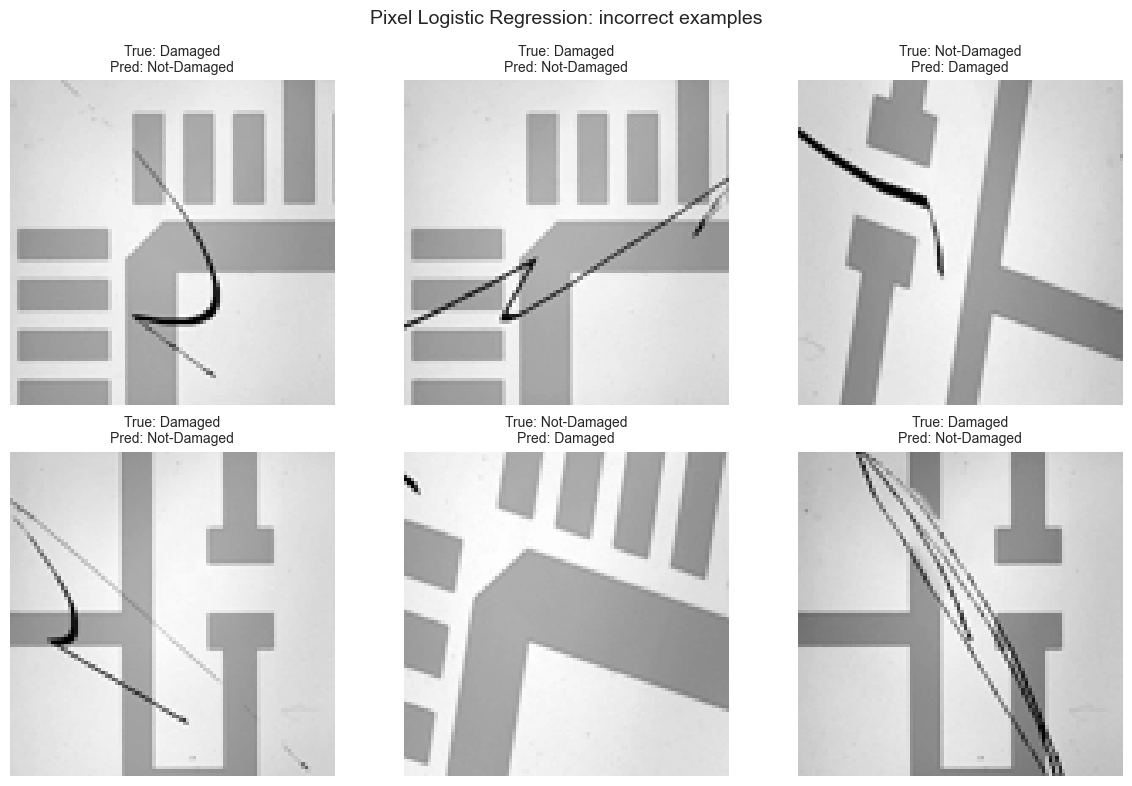

In [14]:
if not RUN_PIXEL_BASELINE:
    display(Markdown("**Pixel baseline skipped:** set `RUN_PIXEL_BASELINE = True` to run it."))
else:
    X_pixels = images_scaled.reshape(len(images_scaled), -1)
    Xp_train, Xp_test, yp_train, yp_test, _, pixel_test_images = train_test_split(
        X_pixels,
        labels,
        images_scaled,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_labels,
    )

    pixel_steps = [("scale", StandardScaler())]
    if USE_PIXEL_PCA:
        pixel_steps.append(("pca", PCA(n_components=PCA_VARIANCE_TO_KEEP, random_state=RANDOM_STATE)))
    pixel_steps.append(("clf", LogisticRegression(max_iter=2000)))
    pixel_model = Pipeline(pixel_steps)

    pixel_results = evaluate_model(
        "Pixel Logistic Regression",
        pixel_model,
        Xp_train,
        yp_train,
        Xp_test,
        yp_test,
        pixel_test_images,
        cmap="Oranges",
    )

## 15. Final comparison summary

,step,seconds
0,dataset_scan,0.011
1,load_grayscale_images,0.896
2,fourier_feature_extraction,0.042
3,fourier_logistic_regression,0.006
4,fourier_linear_svc,0.002
5,pixel_logistic_regression,0.109


,model,accuracy,train_seconds
0,Fourier Logistic Regression,0.791667,0.005763
1,Pixel Logistic Regression,0.625000,0.108872
2,Fourier Linear SVC,0.541667,0.002255


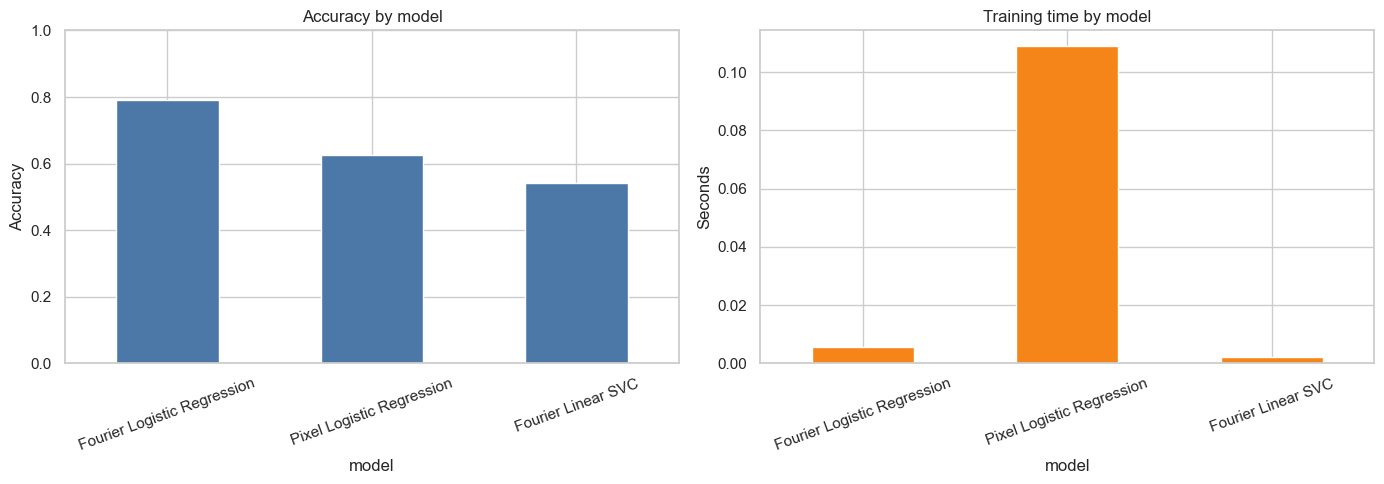

**Reflection prompts:** Did Fourier features help the classifier? Which class pairs were still confused? Did low, middle, or high frequencies seem most useful? What might Fourier features miss because they summarize frequency instead of object location?

In [15]:
runtime_table = timing_frame(step_timings)
display(runtime_table)

comparison_table = pd.DataFrame(model_summaries)
comparison_table = comparison_table.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_table.plot(kind="bar", x="model", y="accuracy", color="#4c78a8", legend=False, ax=axes[0], title="Accuracy by model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

comparison_table.plot(kind="bar", x="model", y="train_seconds", color="#f58518", legend=False, ax=axes[1], title="Training time by model")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(Markdown(
    "**Reflection prompts:** Did Fourier features help the classifier? "
    "Which class pairs were still confused? Did low, middle, or high frequencies seem most useful? "
    "What might Fourier features miss because they summarize frequency instead of object location?"
))

## 16. What students should notice

Fourier features are a different representation of the same images.

- They can be useful when texture, repeated patterns, edges, or blur matter.
- They are compact: this notebook uses dozens of features instead of thousands of pixel values.
- They lose some location information. A scratch in the corner and a scratch in the center may have similar frequency summaries.
- The best representation depends on the decision you need the model to make.

Good experiments to try next:
- Change `FOURIER_BINS`.
- Raise `LOW_FREQUENCY_CUTOFF` to remove broad shape information.
- Lower `HIGH_FREQUENCY_CUTOFF` to remove fine texture.
- Switch `TARGET_MODE` between `damage_status` and `device_type`.